<a href="https://colab.research.google.com/github/AdityaVarma-7558/AdityaVarma-25BAI0189/blob/main/EDA%20Exp%20-%2010%7C06.10.2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Number of training samples: 27455
Number of test samples: 7172
Number of classes: 24
Image dimensions: 28x28 (784 features)
Number of samples per label:
Class 0: 1126
Class 1: 1010
Class 2: 1144
Class 3: 1196
Class 4: 957
Class 5: 1204
Class 6: 1090
Class 7: 1013
Class 8: 1162
Class 10: 1114
Class 11: 1241
Class 12: 1055
Class 13: 1151
Class 14: 1196
Class 15: 1088
Class 16: 1279
Class 17: 1294
Class 18: 1199
Class 19: 1186
Class 20: 1161
Class 21: 1082
Class 22: 1225
Class 23: 1164
Class 24: 1118


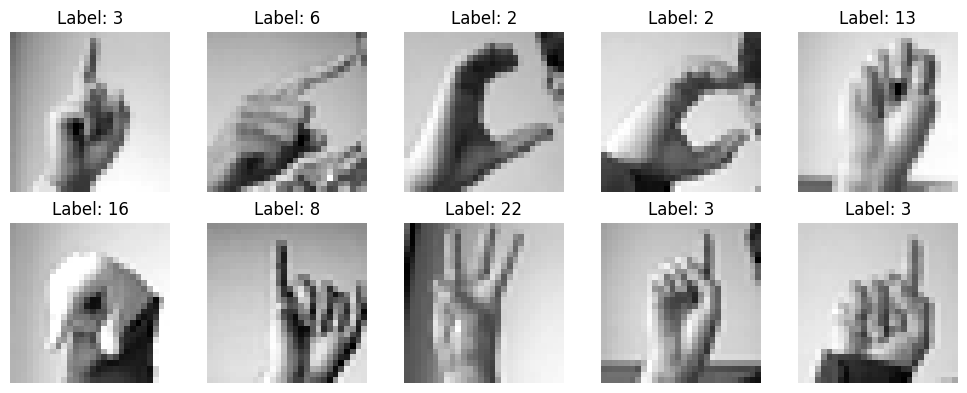

In [1]:
#Part A: Data Understanding and Preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_df = pd.read_csv('sign_mnist_train.csv')
test_df = pd.read_csv('sign_mnist_test.csv')

y_train = train_df.iloc[:, 0].values
X_train = train_df.iloc[:, 1:].values.astype(np.float32)

y_test = test_df.iloc[:, 0].values
X_test = test_df.iloc[:, 1:].values.astype(np.float32)

print(f"Number of training samples: {X_train.shape[0]}")
print(f"Number of test samples: {X_test.shape[0]}")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"Image dimensions: 28x28 ({X_train.shape[1]} features)")

unique_labels, label_counts = np.unique(y_train, return_counts=True)
print("Number of samples per label:")
for label, count in zip(unique_labels, label_counts):
    print(f"Class {label}: {count}")

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

X_train = X_train / 255.0
X_test = X_test / 255.0

Number of components required to retain 90% variance: 58
Number of components required to retain 95% variance: 113
Number of components required to retain 99% variance: 285


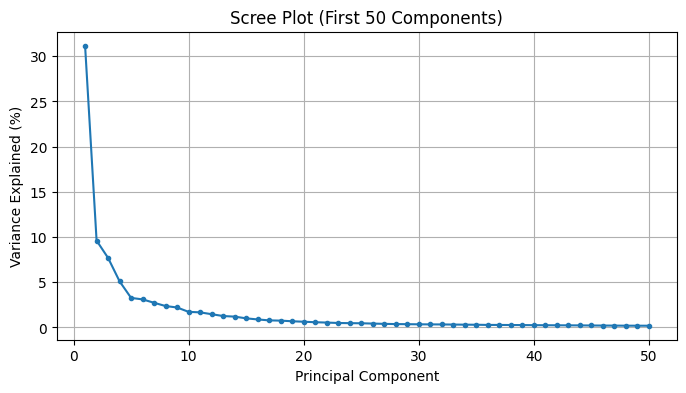

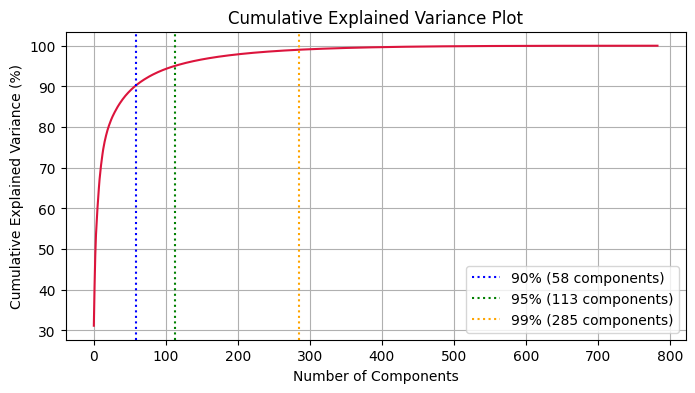

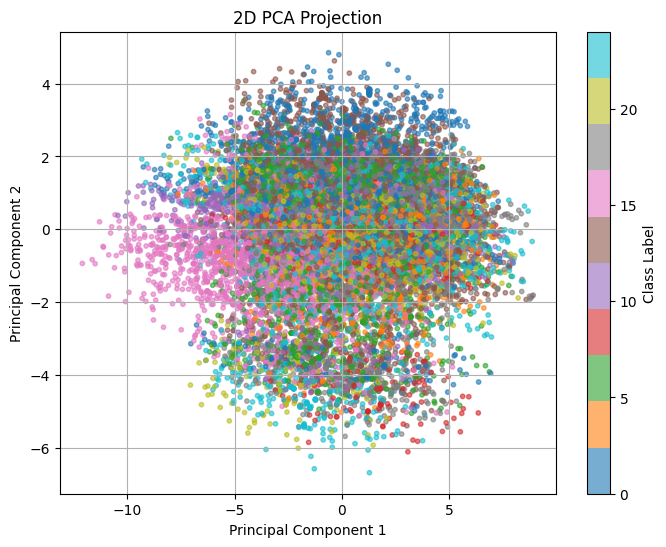

In [2]:
#Part B: Principal Component Analysis (PCA)
from sklearn.decomposition import PCA

pca_all = PCA(random_state=42)
pca_all.fit(X_train)

explained_variance = pca_all.explained_variance_ratio_
cumsum = np.cumsum(explained_variance)

n_90 = np.argmax(cumsum >= 0.90) + 1
n_95 = np.argmax(cumsum >= 0.95) + 1
n_99 = np.argmax(cumsum >= 0.99) + 1

print(f"Number of components required to retain 90% variance: {n_90}")
print(f"Number of components required to retain 95% variance: {n_95}")
print(f"Number of components required to retain 99% variance: {n_99}")

pca_2d = PCA(n_components=2, random_state=42)
X_train_pca_2d = pca_2d.fit_transform(X_train)

pca_50 = PCA(n_components=50, random_state=42)
X_train_pca_50 = pca_50.fit_transform(X_train)
X_test_pca_50 = pca_50.transform(X_test)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 51), explained_variance[:50] * 100, marker='.', linestyle='-')
plt.title('Scree Plot (First 50 Components)')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(cumsum * 100, color='crimson')
plt.axvline(x=n_90, color='blue', linestyle=':', label=f'90% ({n_90} components)')
plt.axvline(x=n_95, color='green', linestyle=':', label=f'95% ({n_95} components)')
plt.axvline(x=n_99, color='orange', linestyle=':', label=f'99% ({n_99} components)')
plt.title('Cumulative Explained Variance Plot')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca_2d[:, 0], X_train_pca_2d[:, 1], c=y_train, cmap='tab10', alpha=0.6, s=10)
plt.colorbar(scatter, label='Class Label')
plt.title('2D PCA Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

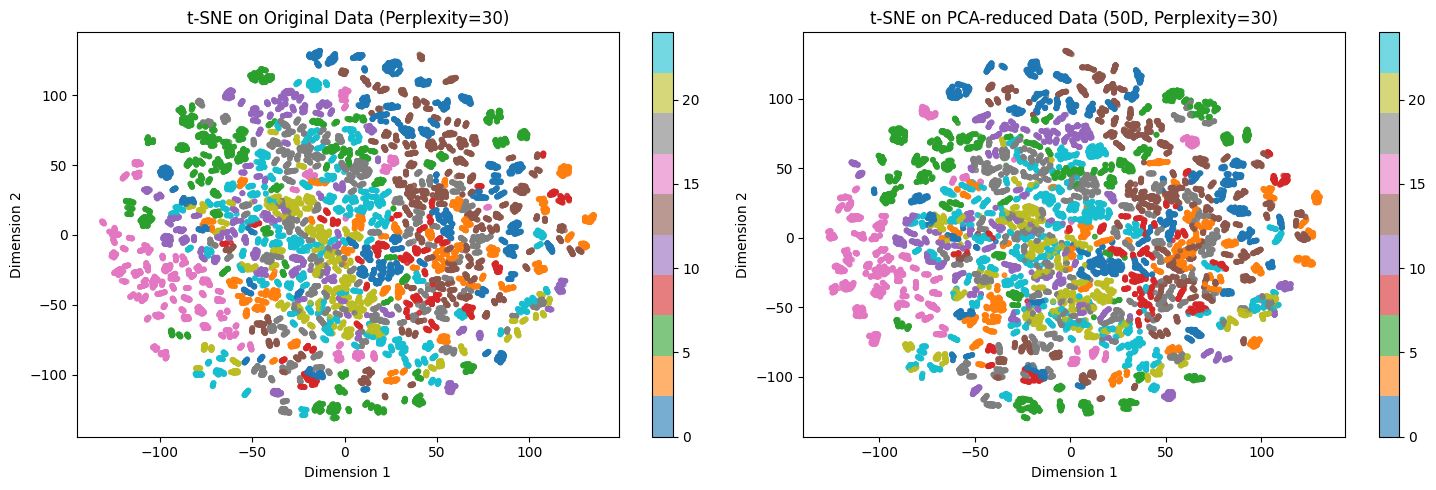

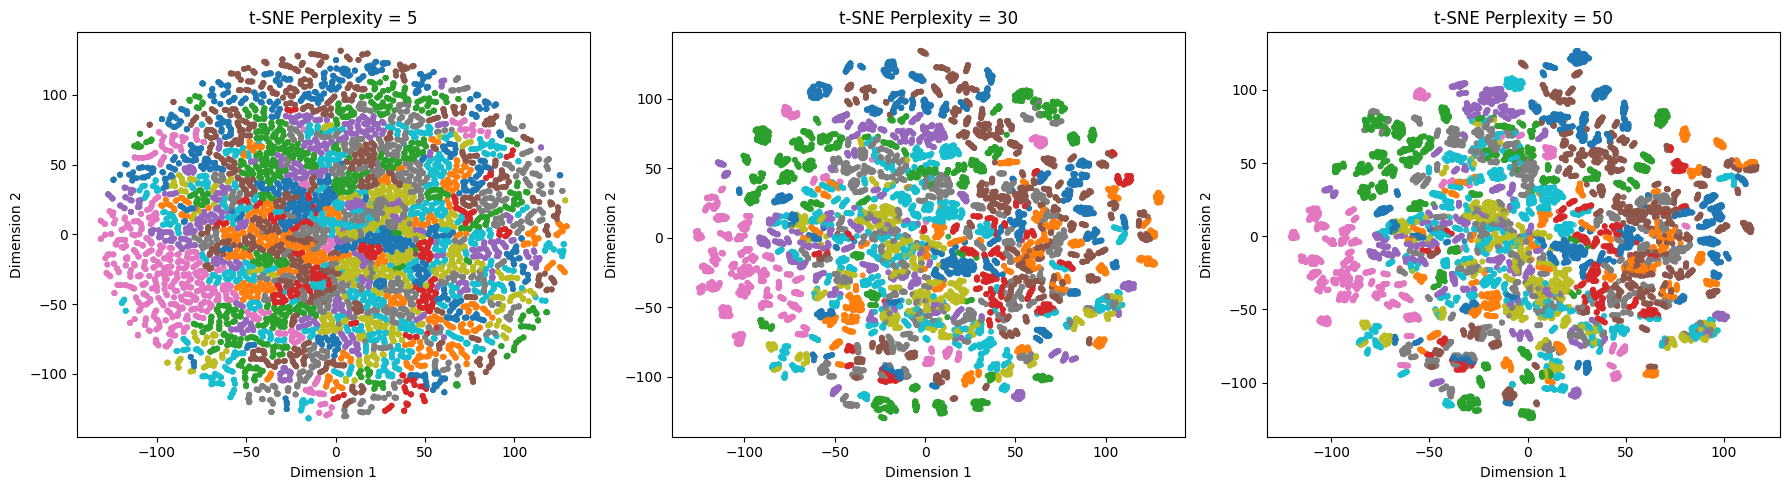

In [3]:
#Part C: t-SNE Visualization
from sklearn.manifold import TSNE

tsne_orig = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne_orig = tsne_orig.fit_transform(X_train)

tsne_pca50 = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne_pca50 = tsne_pca50.fit_transform(X_train_pca_50)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sc1 = axes[0].scatter(X_tsne_orig[:, 0], X_tsne_orig[:, 1], c=y_train, cmap='tab10', alpha=0.6, s=10)
axes[0].set_title('t-SNE on Original Data (Perplexity=30)')
axes[0].set_xlabel('Dimension 1')
axes[0].set_ylabel('Dimension 2')
plt.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(X_tsne_pca50[:, 0], X_tsne_pca50[:, 1], c=y_train, cmap='tab10', alpha=0.6, s=10)
axes[1].set_title('t-SNE on PCA-reduced Data (50D, Perplexity=30)')
axes[1].set_xlabel('Dimension 1')
axes[1].set_ylabel('Dimension 2')
plt.colorbar(sc2, ax=axes[1])
plt.tight_layout()
plt.show()

perplexities = [5, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, perp in enumerate(perplexities):
    tsne_model = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=1000)
    embedding = tsne_model.fit_transform(X_train_pca_50)
    sc = axes[idx].scatter(embedding[:, 0], embedding[:, 1], c=y_train, cmap='tab10', alpha=0.6, s=10)
    axes[idx].set_title(f't-SNE Perplexity = {perp}')
    axes[idx].set_xlabel('Dimension 1')
    axes[idx].set_ylabel('Dimension 2')
plt.tight_layout()
plt.show()

In [4]:
#Part D: Digit / Object Recognition Analysis
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_original = KNeighborsClassifier(n_neighbors=5)
t0 = time.time()
knn_original.fit(X_train, y_train)
t_train_orig = time.time() - t0

t0 = time.time()
y_pred_original = knn_original.predict(X_test)
t_pred_orig = time.time() - t0
accuracy_original = accuracy_score(y_test, y_pred_original)

knn_pca = KNeighborsClassifier(n_neighbors=5)
t0 = time.time()
knn_pca.fit(X_train_pca_50, y_train)
t_train_pca = time.time() - t0

t0 = time.time()
y_pred_pca = knn_pca.predict(X_test_pca_50)
t_pred_pca = time.time() - t0
accuracy_pca = accuracy_score(y_test, y_pred_pca)

print("-" * 55)
print(f"Original data: {X_train.shape[1]} dimensions, Accuracy: {accuracy_original:.4f}")
print(f"PCA data: {X_train_pca_50.shape[1]} dimensions, Accuracy: {accuracy_pca:.4f}")
print("-" * 55)
print(f"Original data training time: {t_train_orig:.4f} s")
print(f"PCA data training time: {t_train_pca:.4f} s")
print(f"Original data prediction time: {t_pred_orig:.4f} s")
print(f"PCA data prediction time: {t_pred_pca:.4f} s")
print("-" * 55)
print(f"Original data memory: {X_train.nbytes / (1024**2):.2f} MB")
print(f"PCA data memory: {X_train_pca_50.nbytes / (1024**2):.2f} MB")
print("-" * 55)

-------------------------------------------------------
Original data: 784 dimensions, Accuracy: 0.8059
PCA data: 50 dimensions, Accuracy: 0.8140
-------------------------------------------------------
Original data training time: 0.0888 s
PCA data training time: 0.0021 s
Original data prediction time: 1.4025 s
PCA data prediction time: 0.2107 s
-------------------------------------------------------
Original data memory: 82.11 MB
PCA data memory: 5.24 MB
-------------------------------------------------------
